## Step 2 — Participation in Ancillary Service Markets

In this step, the participation of a price-taking stochastic flexible load in the DK2 FCR-D Up market is analysed. The flexible load can provide upward frequency containment reserve by quickly reducing its electricity consumption.

A single bidding hour is considered with minute-level resolution. Therefore, each load profile consists of 60 consumption values, one for each minute of the hour.

## Data Generation for Future Stochastic Load

A total of 300 stochastic load profiles are generated. Each load profile satisfies the following conditions:

- Consumption remains between 220 kW and 600 kW.
- Minute-to-minute changes do not exceed 35 kW.

The 300 profiles are split into:

- 100 in-sample profiles, used for the reserve bidding decision.
- 200 out-of-sample profiles, used later for verification.

For FCR-D Up, the flexible load provides reserve by reducing consumption. Therefore, the available upward flexibility is equal to the current consumption level:

$$
F^{\uparrow}_{s,m} = L_{s,m}
$$

where \(L_{s,m}\) is the consumption of profile \(s\) in minute \(m\).

## Task 2.1 — In-Sample Decision Making under the P90 Requirement

The objective is to determine the maximum FCR-D Up reserve capacity bid using the 100 in-sample load profiles.

The decision variable is:

$$
c^{\uparrow}
$$

where \(c^{\uparrow}\) is the FCR-D Up reserve bid in kW.

The P90 requirement means that the offered reserve capacity must be available with at least 90% probability. Equivalently, the probability of reserve shortfall, or overbidding, must be at most 10%.

This task is solved using two methods:

1. ALSO-X / sample-based MILP formulation.
2. CVaR approximation.


## ALSO-X / Sample-Based MILP Formulation

The ALSO-X formulation directly limits the number of sample-minute violations.

A binary variable is introduced:

$$
y_{s,m} =
\begin{cases}
1, & \text{if the reserve bid exceeds available flexibility} \\
0, & \text{otherwise}
\end{cases}
$$

The availability constraint is written as:

$$
c^{\uparrow} - F^{\uparrow}_{s,m} \leq M y_{s,m}
\qquad \forall s,m
$$

where \(M\) is a sufficiently large constant.

If \(y_{s,m}=0\), the reserve bid must be feasible in that minute and scenario. If \(y_{s,m}=1\), a violation is allowed.

The P90 requirement is enforced by limiting the total number of violations:

$$
\sum_s \sum_m y_{s,m}
\leq
\epsilon N M_t
$$

where:

$$
\epsilon = 0.10
$$

\(N\) is the number of in-sample profiles, and \(M_t=60\) is the number of minutes in the bidding hour.

The optimization problem is:

$$
\max c^{\uparrow}
$$

subject to the availability constraints and the violation budget.

In [1]:
# ============================================
# TASK 2.1 — ALSO-X / sample-based MILP
# FCR-D Up reserve bid under P90 requirement
# ============================================

import gurobipy as gp
from gurobipy import GRB
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

load_in = np.load("../data/load_in.npy")
load_out = np.load("../data/load_out.npy")
F_up_in = np.load("../data/F_up_in.npy")
F_up_out = np.load("../data/F_up_out.npy")

N_in, M = F_up_in.shape
N_out, _ = F_up_out.shape

epsilon = 0.10          # P90 requirement -> max 10% violation
M_big = 10000           # Big-M
q = int(epsilon * N_in * M)

model_alsox = gp.Model("Task_2_1_ALSOX_FCRD_Up")
model_alsox.setParam("OutputFlag", 0)

# Decision variable: reserve capacity bid [kW]
c_up = model_alsox.addVar(lb=0, name="c_up")

# Binary violation variable
y = model_alsox.addVars(N_in, M, vtype=GRB.BINARY, name="y")

# If c_up > available flexibility, violation is allowed through y
for s in range(N_in):
    for m in range(M):
        model_alsox.addConstr(
            c_up - F_up_in[s, m] <= M_big * y[s, m],
            name=f"availability_{s}_{m}"
        )

# Violation budget: at most 10% of all sample-minute cases
model_alsox.addConstr(
    gp.quicksum(y[s, m] for s in range(N_in) for m in range(M)) <= q,
    name="P90_violation_budget"
)

# Objective: maximize reserve bid
model_alsox.setObjective(c_up, GRB.MAXIMIZE)

model_alsox.optimize()

if model_alsox.status == GRB.OPTIMAL:
    c_up_alsox = c_up.X
    print("========== ALSO-X / MILP RESULT ==========")
    print(f"Optimal FCR-D Up reserve bid: {c_up_alsox:.2f} kW")
    print(f"Allowed violations: {q} out of {N_in*M}")
    print(f"In-sample violation count: {sum(y[s,m].X for s in range(N_in) for m in range(M)):.0f}")
else:
    print("ALSO-X model not optimal. Status:", model_alsox.status)

Set parameter Username
Set parameter LicenseID to value 2783196
Academic license - for non-commercial use only - expires 2027-02-25
========== ALSO-X / MILP RESULT ==========
Optimal FCR-D Up reserve bid: 242.21 kW
Allowed violations: 600 out of 6000
In-sample violation count: 600


## CVaR Approximation

The CVaR formulation approximates the P90 requirement by controlling the magnitude of reserve shortfalls.

The reserve shortfall is defined as:

$$
\xi_{s,m} \geq c^{\uparrow} - F^{\uparrow}_{s,m}
$$

$$
\xi_{s,m} \geq 0
$$

Instead of only counting how often the reserve bid is infeasible, CVaR also accounts for how large the infeasibility is.

The CVaR formulation is linear and avoids binary variables. However, because it controls the size of shortfalls, it is usually more conservative than ALSO-X.

In [2]:
# ============================================
# TASK 2.1 — CVaR approximation
# FCR-D Up reserve bid under P90 requirement
# ============================================

model_cvar = gp.Model("Task_2_1_CVaR_FCRD_Up")
model_cvar.setParam("OutputFlag", 0)

# Decision variable: reserve capacity bid [kW]
c_up_cvar = model_cvar.addVar(lb=0, name="c_up")

# CVaR variables
beta = model_cvar.addVar(ub=0, name="beta")          # VaR-like threshold
shortfall = model_cvar.addVars(N_in, M, lb=-GRB.INFINITY, name="shortfall")

# Shortfall constraints
for s in range(N_in):
    for m in range(M):
        model_cvar.addConstr(
            c_up_cvar - F_up_in[s, m] <= shortfall[s, m],
            name=f"shortfall_{s}_{m}"
        )

        model_cvar.addConstr(
            beta <= shortfall[s, m],
            name=f"beta_bound_{s}_{m}"
        )

# CVaR conservative approximation
model_cvar.addConstr(
    gp.quicksum(shortfall[s, m] for s in range(N_in) for m in range(M)) / (N_in * M)
    <= (1 - epsilon) * beta,
    name="CVaR_constraint"
)

# Objective: maximize reserve bid
model_cvar.setObjective(c_up_cvar, GRB.MAXIMIZE)

model_cvar.optimize()

if model_cvar.status == GRB.OPTIMAL:
    c_up_cvar_val = c_up_cvar.X
    print("\n========== CVaR RESULT ==========")
    print(f"Optimal FCR-D Up reserve bid: {c_up_cvar_val:.2f} kW")
    print(f"beta value: {beta.X:.2f}")
else:
    print("CVaR model not optimal. Status:", model_cvar.status)


========== CVaR RESULT ==========
Optimal FCR-D Up reserve bid: 220.00 kW
beta value: 0.00


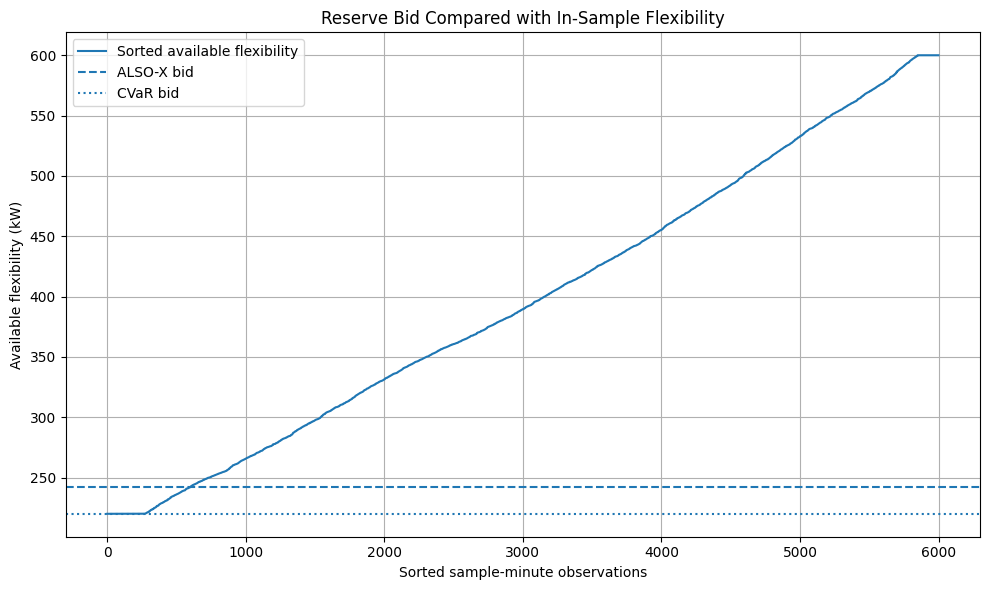

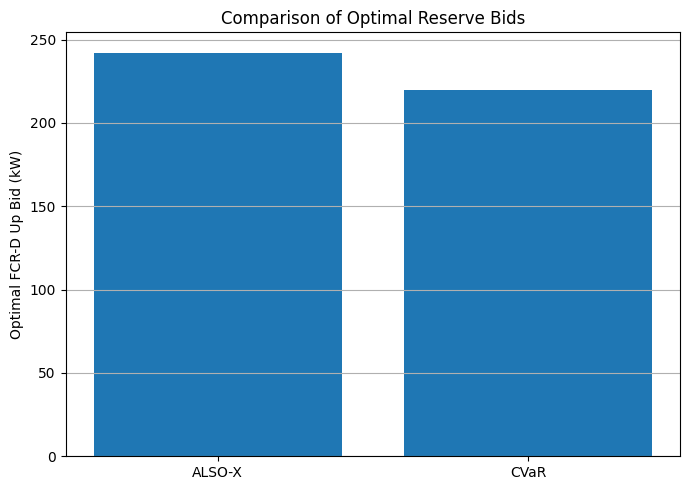

In [3]:
# ============================================
# Task 2.1 Summary
# ============================================

task_2_1_results = pd.DataFrame({
    "Method": ["ALSO-X / MILP", "CVaR approximation"],
    "Optimal reserve bid [kW]": [c_up_alsox, c_up_cvar_val]
})

task_2_1_results



all_flex = F_up_in.flatten()
sorted_flex = np.sort(all_flex)

plt.figure(figsize=(10,6))

plt.plot(sorted_flex, label="Sorted available flexibility")
plt.axhline(c_up_alsox, linestyle="--", label="ALSO-X bid")
plt.axhline(c_up_cvar_val, linestyle=":", label="CVaR bid")

plt.xlabel("Sorted sample-minute observations")
plt.ylabel("Available flexibility (kW)")
plt.title("Reserve Bid Compared with In-Sample Flexibility")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7,5))

plt.bar(
    ["ALSO-X", "CVaR"],
    [c_up_alsox, c_up_cvar_val]
)

plt.ylabel("Optimal FCR-D Up Bid (kW)")
plt.title("Comparison of Optimal Reserve Bids")
plt.grid(axis="y")
plt.tight_layout()
plt.show()